In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [15]:
df = pd.read_excel('E Commerce Dataset.xlsx', sheet_name='E Comm')
print("--- 1. Info Data Awal ---")
df.info()

--- 1. Info Data Awal ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   objec

In [16]:
kolom_angka = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 
               'OrderAmountHikeFromlastYear', 'CouponUsed', 
               'OrderCount', 'DaySinceLastOrder']

for kolom in kolom_angka:
    df[kolom] = pd.to_numeric(df[kolom], errors='coerce')
    df[kolom].fillna(df[kolom].median(), inplace=True)

df.drop_duplicates(inplace=True)

print("--- 2. Cek Missing Values SESUDAH Cleaning ---")
sisa_kosong = df.isnull().sum()[df.isnull().sum() > 0]
if sisa_kosong.empty:
    print("(0 Missing Values).")
else:
    display(sisa_kosong)

--- 2. Cek Missing Values SESUDAH Cleaning ---
(0 Missing Values).


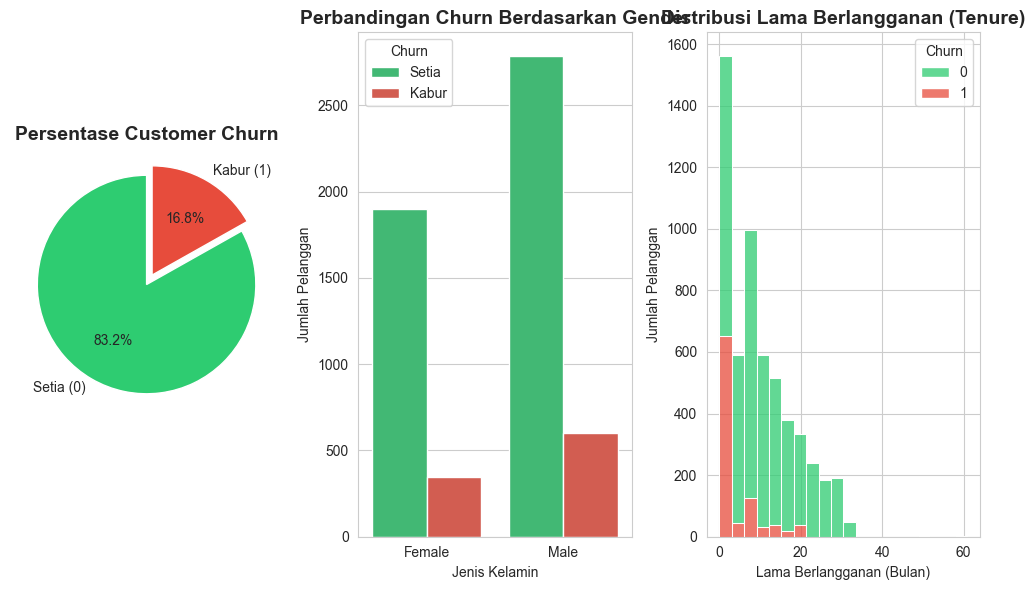

In [17]:
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))

# Grafik 1: Persentase Pelanggan yang Kabur vs Setia
plt.subplot(1, 3, 1)
df['Churn'].value_counts().plot.pie(
    autopct='%1.1f%%', 
    colors=['#2ecc71', '#e74c3c'], 
    labels=['Setia (0)', 'Kabur (1)'],
    explode=(0, 0.1), # Efek potongan pie sedikit keluar
    startangle=90
)
plt.title('Persentase Customer Churn', fontweight='bold', fontsize=14)
plt.ylabel('')

# Grafik 2: Apakah Gender ngaruh ke Churn?
plt.subplot(1, 3, 2)
sns.countplot(data=df, x='Gender', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Perbandingan Churn Berdasarkan Gender', fontweight='bold', fontsize=14)
plt.xlabel('Jenis Kelamin')
plt.ylabel('Jumlah Pelanggan')
plt.legend(title='Churn', labels=['Setia', 'Kabur'])

# Grafik 3: Apakah Lama Berlangganan (Tenure) ngaruh?
plt.subplot(1, 3, 3)
sns.histplot(data=df, x='Tenure', hue='Churn', multiple='stack', bins=20, palette=['#2ecc71', '#e74c3c'])
plt.title('Distribusi Lama Berlangganan (Tenure)', fontweight='bold', fontsize=14)
plt.xlabel('Lama Berlangganan (Bulan)')
plt.ylabel('Jumlah Pelanggan')

plt.tight_layout()
plt.show()

In [ ]:
print(" Mengubah data teks menjadi angka...")
# pd.get_dummies akan otomatis mengubah semua kolom teks menjadi angka (0 dan 1)
df_ml = pd.get_dummies(df, drop_first=True)

🔄 Mengubah data teks menjadi angka...


In [19]:
# Memisahkan mana "(X) dan (y)
# Target (y) kita adalah kolom 'Churn'
X = df_ml.drop('Churn', axis=1) # X berisi semua kolom KECUALI Churn
y = df_ml['Churn']              # y HANYA berisi kolom Churn

In [20]:
# Membagi data: 80% untuk (Training), 20% untuk (Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_test)

akurasi = accuracy_score(y_test, y_pred)
print(f"TINGKAT AKURASI MODEL: {akurasi * 100:.2f}%\n")

print(" --- (Classification Report) ---")
print(classification_report(y_test, y_pred))

TINGKAT AKURASI MODEL: 96.00%

 --- (Classification Report) ---
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       941
           1       0.99      0.76      0.86       185

    accuracy                           0.96      1126
   macro avg       0.97      0.88      0.92      1126
weighted avg       0.96      0.96      0.96      1126



Membuat grafik Faktor Utama penyebab Churn...



C:\Users\fadjr\AppData\Local\Temp\ipykernel_6196\1713866807.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


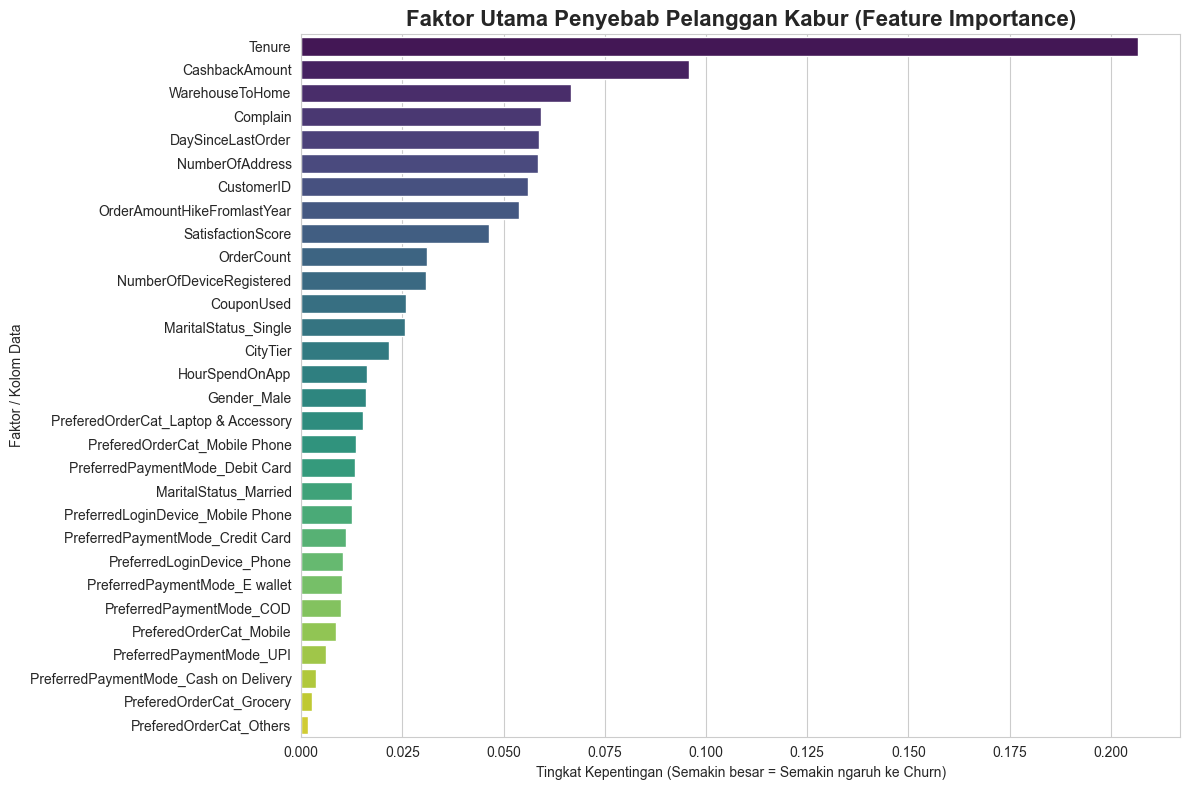

In [23]:
# ==========================================
# FEATURE IMPORTANCE (FAKTOR UTAMA CHURN)
# ==========================================
print("Membuat grafik Faktor Utama penyebab Churn...\n")

# Mengambil nilai "kepentingan" dari model AI yang sudah belajar tadi
importances = model_rf.feature_importances_

# Menggabungkan nama kolom dengan nilai kepentingannya ke dalam sebuah tabel
feature_imp_df = pd.DataFrame({
    'Faktor': X.columns,
    'Kepentingan': importances
})

# Mengurutkan dari faktor yang PALING PENTING (paling atas) ke yang kurang penting
feature_imp_df = feature_imp_df.sort_values(by='Kepentingan', ascending=False)

# --- Membuat Grafik Bar ---
plt.figure(figsize=(12, 8))
sns.barplot(
    data=feature_imp_df, 
    x='Kepentingan', 
    y='Faktor', 
    palette='viridis' # Menggunakan tema warna gradasi yang elegan
)

plt.title('Faktor Utama Penyebab Pelanggan Kabur (Feature Importance)', fontweight='bold', fontsize=16)
plt.xlabel('Tingkat Kepentingan (Semakin besar = Semakin ngaruh ke Churn)')
plt.ylabel('Faktor / Kolom Data')
plt.tight_layout()
plt.show()

In [24]:
df.to_excel('ECommerce_Dataset_Cleaned.xlsx', index=False)

In [29]:
# ==========================================
# RADAR PENDETEKSI CHURN (PROBABILITAS)
# ==========================================
print(" Mengaktifkan Radar Pendeteksi Churn...\n")

# Saya ambil 15 pelanggan acak dari data yang belum pernah dilihat AI (X_test)
pelanggan_baru = X_test.sample(5, random_state=88)

# Menggunakan predict_proba untuk melihat persentase
# Hasilnya adalah dua angka: [Peluang Setia(0), Peluang Kabur(1)]
probabilitas = model_rf.predict_proba(pelanggan_baru)

# Buat perulangan untuk menampilkan hasilnya agar enak dibaca bos
for i, prob in enumerate(probabilitas):
    # prob[1] adalah persentase untuk kelas 1 (Kabur)
    persen_kabur = prob[1] * 100 
    
    print(f"Pelanggan #{i+1}:")
    print(f"   Kemungkinan Kabur : {persen_kabur:.1f}%")
    
    # Memberikan rekomendasi otomatis berdasarkan persentase
    if persen_kabur >= 70:
        print("   Status :  BAHAYA TINGGI! Segera telepon dan kasih Cashback VIP!")
    elif persen_kabur >= 40:
        print("   Status :  WASPADA. Kirimkan notifikasi promo ke HP-nya.")
    else:
        print("   Status :  AMAN. Pelanggan ini setia, simpan budget promo Anda.")
    print("-" * 60)

 Mengaktifkan Radar Pendeteksi Churn...

Pelanggan #1:
   Kemungkinan Kabur : 3.0%
   Status :  AMAN. Pelanggan ini setia, simpan budget promo Anda.
------------------------------------------------------------
Pelanggan #2:
   Kemungkinan Kabur : 2.0%
   Status :  AMAN. Pelanggan ini setia, simpan budget promo Anda.
------------------------------------------------------------
Pelanggan #3:
   Kemungkinan Kabur : 20.0%
   Status :  AMAN. Pelanggan ini setia, simpan budget promo Anda.
------------------------------------------------------------
Pelanggan #4:
   Kemungkinan Kabur : 3.0%
   Status :  AMAN. Pelanggan ini setia, simpan budget promo Anda.
------------------------------------------------------------
Pelanggan #5:
   Kemungkinan Kabur : 0.0%
   Status :  AMAN. Pelanggan ini setia, simpan budget promo Anda.
------------------------------------------------------------


In [ ]:
# ==========================================
#  EXPORT DAFTAR TARGET PROMO
# ==========================================
print("Mempersiapkan Daftar Target Promo untuk Tim Marketing...")

# 1. Kita suruh ML menebak probabilitas (persentase) untuk SEMUA pelanggan di dataset (X)
semua_prediksi = model_rf.predict_proba(X)

# 2. Ambil persentase kaburnya saja (indeks 1) dan ubah ke format persen (0-100)
persen_kabur_semua = semua_prediksi[:, 1] * 100

# 3. Gabungkan hasil tebakan ML ini ke data asli kita biar rapi
df_final = df.copy() # Menggunakan data awal agar teks seperti 'Male'/'Female' tetap terbaca
df_final['Risiko_Kabur (%)'] = persen_kabur_semua.round(2)

# 4. Urutkan dari pelanggan yang risikonya PALING TINGGI (paling atas) ke yang aman
df_final = df_final.sort_values(by='Risiko_Kabur (%)', ascending=False)

# 5. Simpan ke dalam file Excel baru
df_final.to_excel('Daftar_Target_Promo_Marketing.xlsx', index=False)


Mempersiapkan Daftar Target Promo untuk Tim Marketing...
File 'Daftar_Target_Promo_Marketing.xlsx' sudah berhasil dibuat di folder kamu.
